### Pacotes importados

In [5]:
# codigo aqui

## Chapter 9: Quadratic problems

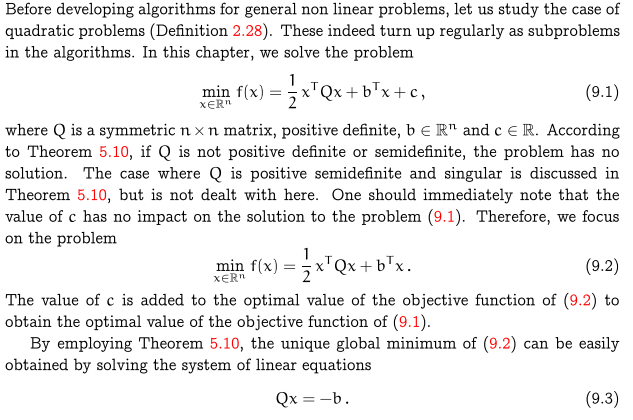

### Algorithm 9.1: quadratic problems: direct solution

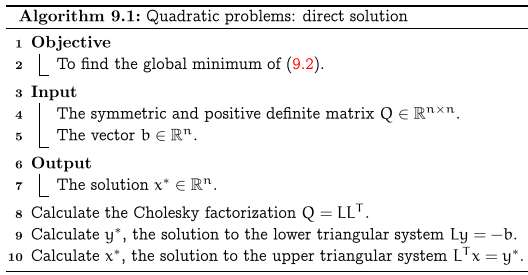

Example 9.8: $Q=\left(\begin{array}{cccc} 1& 1 & 1 & 1 \\ 1 & 2 & 2 & 2 \\ 1 & 2 & 3 & 3 \\ 1 & 2 & 3 & 4\end{array}\right)$, $b=\left(\begin{array}{c}-4 \\ -7 \\ -9 \\ -10\end{array}\right)$. First, confirm Q is P.D.

In [6]:
# Algoritmo 9.1 - Problema Quadrático: Solução Direta via Cholesky
# min f(x) = (1/2) xᵀQx + bᵀx
# Qx = -b  →  solução via fatoração de Cholesky Q = LLᵀ

using LinearAlgebra
using Printf

# Dados do Example 9.8
Q = [1 1 1 1;
     1 2 2 2;
     1 2 3 3;
     1 2 3 4]

b = [-4.0, -7.0, -9.0, -10.0]

# ── Passo 1: Verificar se Q é positiva definida ──────────────────────────
eigenvalues = eigvals(Q)
println("Autovalores de Q:")
for (i, λ) in enumerate(eigenvalues)
    @printf("  λ%d = %+.8E\n", i, λ)
end

is_pd = all(eigenvalues .> 0)
println("\nQ é positiva definida? ", is_pd ? "✓ SIM" : "✗ NÃO")

# ── Passo 2: Fatoração de Cholesky Q = LLᵀ ──────────────────────────────
C = cholesky(Q)
L = C.L
println("\nFator de Cholesky L (Q = LLᵀ):")
for i in 1:size(L,1)
    print("  [")
    for j in 1:size(L,2)
        @printf(" %+.8E", L[i,j])
    end
    println(" ]")
end

# Verificação: L * Lᵀ ≈ Q
println("\nVerificação L·Lᵀ ≈ Q: erro = ", norm(L * L' - Q))

# ── Passo 3: Resolver Ly = -b (sistema triangular inferior) ─────────────
y = L \ (-b)
println("\nSolução de Ly = -b:")
for (i, yi) in enumerate(y)
    @printf("  y%d = %+.8E\n", i, yi)
end

# ── Passo 4: Resolver Lᵀx = y (sistema triangular superior) ────────────
x_star = L' \ y
println("\nSolução x* de Lᵀx = y:")
for (i, xi) in enumerate(x_star)
    @printf("  x%d* = %+.8E\n", i, xi)
end

# ── Verificação final ────────────────────────────────────────────────────
residuo = norm(Q * x_star + b)
fval    = 0.5 * x_star' * Q * x_star + b' * x_star
println("\nVerificação ||Qx* + b|| = ", residuo)
println("Valor ótimo f(x*)       = ", fval)


Autovalores de Q:
  λ1 = +2.83118583E-01
  λ2 = +4.26022048E-01
  λ3 = +1.00000000E+00
  λ4 = +8.29085937E+00

Q é positiva definida? ✓ SIM

Fator de Cholesky L (Q = LLᵀ):
  [ +1.00000000E+00 +0.00000000E+00 +0.00000000E+00 +0.00000000E+00 ]
  [ +1.00000000E+00 +1.00000000E+00 +0.00000000E+00 +0.00000000E+00 ]
  [ +1.00000000E+00 +1.00000000E+00 +1.00000000E+00 +0.00000000E+00 ]
  [ +1.00000000E+00 +1.00000000E+00 +1.00000000E+00 +1.00000000E+00 ]

Verificação L·Lᵀ ≈ Q: erro = 0.0

Solução de Ly = -b:
  y1 = +4.00000000E+00
  y2 = +3.00000000E+00
  y3 = +2.00000000E+00
  y4 = +1.00000000E+00

Solução x* de Lᵀx = y:
  x1* = +1.00000000E+00
  x2* = +1.00000000E+00
  x3* = +1.00000000E+00
  x4* = +1.00000000E+00

Verificação ||Qx* + b|| = 0.0
Valor ótimo f(x*)       = -15.0


### Algorithm 9.2: Conjugate gradient method

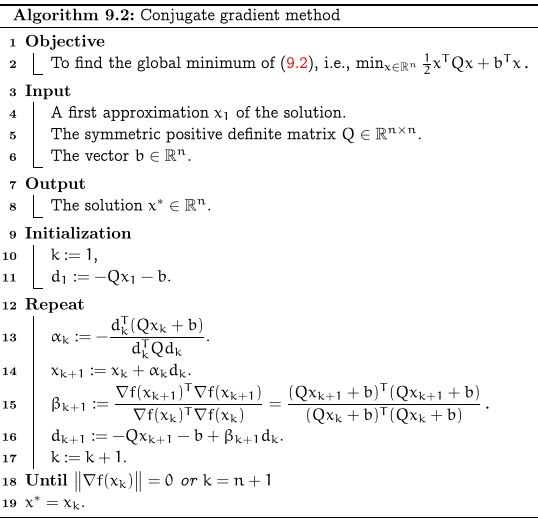

Run the algorithm from $x_0=\left(\begin{array}{c}5 \\ 5 \\ 5 \\ 5 \end{array}\right)$.

k 	 x1 			 x2 			 ||∇f(xk)|| 	 f(xk)
1 	 +5.00000000E+00 	 +5.00000000E+00 	 +6.27375486E+01 	 +2.25000000E+02
2 	 +3.06774669E+00 	 +1.61855670E+00 	 +2.08593555E+00 	 -1.26671576E+01
3 	 +1.49689643E+00 	 +6.10224162E-01 	 +2.77585326E-01 	 -1.49069742E+01
4 	 +1.02806438E+00 	 +9.38093273E-01 	 +3.12027374E-02 	 -1.49983492E+01
5 	 +1.00000000E+00 	 +1.00000000E+00 	 +7.29490069E-12 	 -1.50000000E+01

x* = [0.9999999999997988, 0.9999999999996225, 0.9999999999994911, 0.9999999999994238]
f(x*) = -15.000000000000002
Convergiu em 4 iterações (n = 4)

Solução exata (Qx = -b): [1.0, 1.0, 1.0, 1.0]
Erro ||x* - x_exact|| = 8.79759807339928e-13


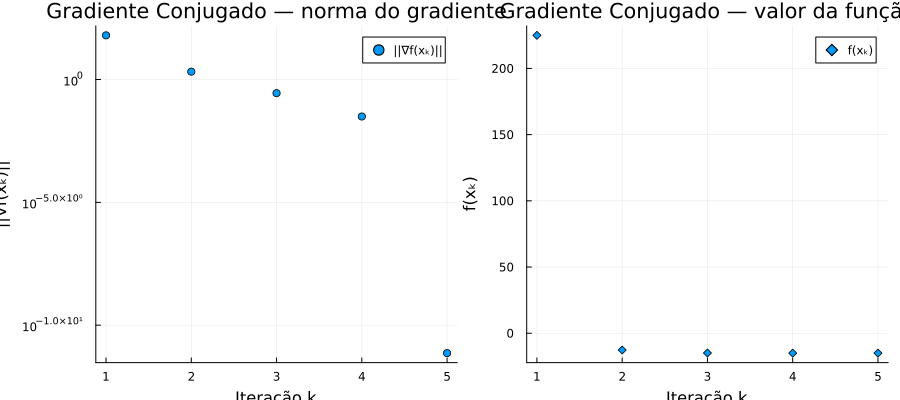

In [7]:
# Algoritmo 9.2 - Método do Gradiente Conjugado
# min f(x) = (1/2) xᵀQx + bᵀx
# Q e b do Example 9.8, x₀ = [5, 5, 5, 5]

using LinearAlgebra
using Printf
using Plots

# Dados (mesmos do Alg. 9.1)
Q = [1 1 1 1;
     1 2 2 2;
     1 2 3 3;
     1 2 3 4]

b = [-4.0, -7.0, -9.0, -10.0]

# Gradiente de f: ∇f(x) = Qx + b
∇f(x) = Q * x + b

# Parâmetros
x = [5.0, 5.0, 5.0, 5.0]   # x₁ (notação do algoritmo: índice começa em 1)
n = length(x)
k = 1

# Inicialização
d = -Q * x - b              # d₁ := -Qx₁ - b = -∇f(x₁)

ks    = Int[]
grads = Float64[]
fvals = Float64[]

println("k \t x1 \t\t\t x2 \t\t\t ||∇f(xk)|| \t f(xk)")

push!(ks, k); push!(grads, norm(∇f(x))); push!(fvals, 0.5*x'*Q*x + b'*x)
@printf("%d \t %+.8E \t %+.8E \t %+.8E \t %+.8E\n",
        k, x[1], x[2], norm(∇f(x)), 0.5*x'*Q*x + b'*x)

# Loop principal
while norm(∇f(x)) > 1e-14 && k <= n

    # Passo 13: tamanho do passo αk
    gk = ∇f(x)                          # = Qxk + b
    αk = -(d' * gk) / (d' * Q * d)

    # Passo 14: atualizar iterado
    x = x + αk * d

    # Passo 15: calcular βk+1 (Fletcher-Reeves)
    g_new = ∇f(x)                        # = Qx(k+1) + b
    βk1   = (g_new' * g_new) / (gk' * gk)

    # Passo 16: atualizar direção conjugada
    d = -g_new + βk1 * d

    k += 1
    push!(ks, k); push!(grads, norm(∇f(x))); push!(fvals, 0.5*x'*Q*x + b'*x)
    @printf("%d \t %+.8E \t %+.8E \t %+.8E \t %+.8E\n",
            k, x[1], x[2], norm(∇f(x)), 0.5*x'*Q*x + b'*x)
end

println("\nx* = ", x)
println("f(x*) = ", 0.5*x'*Q*x + b'*x)
println("Convergiu em ", k-1, " iterações (n = $n)")

# Verificação com solução direta
x_exact = Q \ (-b)
println("\nSolução exata (Qx = -b): ", x_exact)
println("Erro ||x* - x_exact|| = ", norm(x - x_exact))

# Gráficos
p1 = plot(ks, grads,
    seriestype = :scatter, marker = :circle,
    xlabel = "Iteração k", ylabel = "||∇f(xₖ)||",
    title = "Gradiente Conjugado — norma do gradiente",
    yscale = :log10, yformatter = :scientific,
    label = "||∇f(xₖ)||", legend = :topright)

p2 = plot(ks, fvals,
    seriestype = :scatter, marker = :diamond,
    xlabel = "Iteração k", ylabel = "f(xₖ)",
    title = "Gradiente Conjugado — valor da função",
    label = "f(xₖ)", legend = :topright)

plot(p1, p2, layout = (1,2), size = (900, 400))

An error is triggered if the matrix is not definite positive. Here, $Q=\left(\begin{array}{cccc} 1& 2 & 3 & 4 \\ 5 & 6 & 7 & 8 \\ 9 & 10 & 11 & 12 \\ 13 & 14 & 15 & 16\end{array}\right)$

In [8]:
# Algoritmo 9.2 - Método do Gradiente Conjugado
# Teste com Q não positiva definida — deve disparar erro
# x₀ = [5, 5, 5, 5]

using LinearAlgebra
using Printf

Q = [1  2  3  4;
     5  6  7  8;
     9  10 11 12;
     13 14 15 16]

b = [-4.0, -7.0, -9.0, -10.0]

# ── Verificação de positiva definida ────────────────────────────────────
println("=== Verificação de Positiva Definida ===\n")

# Critério 1: autovalores
eigenvalues = eigvals(Q)
println("Autovalores de Q:")
for (i, λ) in enumerate(eigenvalues)
    @printf("  λ%d = %+.8E\n", i, λ)
end

is_pd = all(eigenvalues .> 0)
println("\nTodos os autovalores > 0? ", is_pd ? "✓ SIM" : "✗ NÃO")

# Critério 2: simetria
is_sym = issymmetric(Q)
println("Q é simétrica?            ", is_sym ? "✓ SIM" : "✗ NÃO")

# Critério 3: tentativa de Cholesky (dispara erro se não P.D.)
println("\n=== Tentativa de Fatoração de Cholesky ===\n")
try
    C = cholesky(Q)
    println("✓ Cholesky bem sucedida — Q é positiva definida.")
catch e
    println("✗ ERRO na fatoração de Cholesky:")
    println("  ", e)
end

# ── Tentativa de rodar o Gradiente Conjugado mesmo assim ────────────────
println("\n=== Tentativa de rodar o Gradiente Conjugado ===\n")

∇f(x) = Q * x + b

x = [5.0, 5.0, 5.0, 5.0]
n = length(x)
k = 1
d = -Q * x - b
maxiter = 20

println("k \t ||∇f(xk)|| \t\t αk \t\t\t dᵀQd (deve ser > 0)")

@printf("%d \t %+.8E \t ---\t\t\t ---\n", k, norm(∇f(x)))

divergiu = false

while norm(∇f(x)) > 1e-14 && k <= maxiter

    gk   = ∇f(x)
    dQd  = d' * Q * d           # deve ser > 0 se Q é P.D.
    αk   = -(d' * gk) / dQd

    if dQd <= 0
        @printf("%d \t %+.8E \t %+.8E \t %+.8E  ← ✗ NÃO POSITIVO!\n",
                k, norm(gk), αk, dQd)
        println("\n✗ ERRO: dᵀQd ≤ 0 na iteração k=$k.")
        println("  O método do Gradiente Conjugado requer Q positiva definida.")
        println("  Com dᵀQd ≤ 0, o passo αk não minimiza f na direção dk.")
        divergiu = true
        break
    end

    x    = x + αk * d
    g_new = ∇f(x)
    βk1  = (g_new' * g_new) / (gk' * gk)
    d    = -g_new + βk1 * d

    k += 1
    @printf("%d \t %+.8E \t %+.8E \t %+.8E\n", k, norm(∇f(x)), αk, dQd)
end

if !divergiu && norm(∇f(x)) <= 1e-14
    println("\nx* = ", x)
end

=== Verificação de Positiva Definida ===

Autovalores de Q:
  λ1 = -2.20937271E+00
  λ2 = -2.62410379E-15
  λ3 = -9.51420961E-17
  λ4 = +3.62093727E+01

Todos os autovalores > 0? ✗ NÃO
Q é simétrica?            ✗ NÃO

=== Tentativa de Fatoração de Cholesky ===

✗ ERRO na fatoração de Cholesky:
  PosDefException(-1)

=== Tentativa de rodar o Gradiente Conjugado ===

k 	 ||∇f(xk)|| 		 αk 			 dᵀQd (deve ser > 0)
1 	 +3.68844141E+02 	 ---			 ---
2 	 +1.32340533E+01 	 +2.80002058E-02 	 +4.85875000E+06
2 	 +1.32340533E+01 	 -4.48992207E-01 	 -3.90073958E+02  ← ✗ NÃO POSITIVO!

✗ ERRO: dᵀQd ≤ 0 na iteração k=2.
  O método do Gradiente Conjugado requer Q positiva definida.
  Com dᵀQd ≤ 0, o passo αk não minimiza f na direção dk.
